In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.patches import Wedge, Circle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap


# ============================================================
#  Pomocnicze
# ============================================================
def log_abs_values(values, eps=1e-12):
    """
    Zwraca log10(abs(values) + eps).

    Przydatne do rysowania amplitud spinów w skali logarytmicznej.
    eps zabezpiecza przed log10(0).
    """
    return np.log10(np.abs(values) + eps)

def as_bool(x):
    if isinstance(x, str):
        return x.lower() == "true"
    return bool(x)


def yperiodic_string(x):
    return "true" if as_bool(x) else "false"


def results_geometry_folder(plot_type):
    """
    Zamienia nazwę geometrii używaną w funkcjach rysujących
    na nazwę katalogu w results/.

    Przykłady:
        plot_type="pila"      -> results/saw/
        plot_type="truesnake" -> results/truesnake/
    """
    key = str(plot_type).lower()

    if key in ["pila", "piła", "bottom", "bottomup", "bottom-up", "saw"]:
        return "saw"

    if key in ["truesnake", "true_snake", "true-snake"]:
        return "truesnake"

    if key in ["snake", "semisnake", "semi-snake"]:
        return "snake"

    if key in ["snake_rows", "rows", "horizontal", "row-snake"]:
        return "snake_rows"

    raise ValueError(
        "Nieznany plot_type. Dostępne ścieżki: "
        "'saw'/'pila', 'truesnake', 'snake', 'snake_rows'."
    )


def load_component(path):
    with open(path, "r", encoding="utf-8") as f:
        header = f.readline().strip()

    mg_sites = [int(x) for x in header.replace("#", "").split() if x != "i"]

    data = np.loadtxt(path)
    sites = data[:, 0].astype(int)
    vals = data[:, 1:]

    return sites, vals, mg_sites


def shorten_segment(p1, p2, frac=0.22):
    p1 = np.array(p1, float)
    p2 = np.array(p2, float)
    d = p2 - p1
    return p1 + frac * d, p2 - frac * d


def max_scatter_s_no_overlap(ax, pos_xy, safety=0.85):
    disp = ax.transData.transform(pos_xy)

    dmin2 = np.inf
    for i in range(len(disp)):
        di = disp[i] - disp
        dist2 = di[:, 0]**2 + di[:, 1]**2
        dist2[i] = np.inf
        dmin2 = min(dmin2, dist2.min())

    dmin_px = np.sqrt(dmin2)
    diameter_px = dmin_px * safety
    radius_px = diameter_px / 2.0

    dpi = ax.figure.dpi
    radius_pt = radius_px * 72.0 / dpi

    return np.pi * radius_pt**2


def site_radius_from_geometry(pos, scale=0.33):
    dmin = np.inf

    for i in range(len(pos)):
        d = pos[i] - pos
        dist = np.sqrt(d[:, 0]**2 + d[:, 1]**2)
        dist[i] = np.inf
        dmin = min(dmin, dist.min())

    return scale * dmin


# ============================================================
#  Typy numeracji / bondów
# ============================================================

def bonds_pila(Nx, Ny, yperiodic=False):
    """
    Klasyczna numeracja typu piła / bottom-up.
    """
    Nsites = 2 * Nx * Ny
    bonds = []

    for i in range(1, Nsites):
        if i % 2 == 1:
            bonds.append((i, i + 1, "xx"))
        else:
            if i <= 2 * Ny * (Nx - 1):
                bonds.append((i, i + 2 * Ny - 1, "yy"))

            if i % (2 * Ny) != 0:
                bonds.append((i, i + 1, "zz"))
            elif yperiodic:
                col_start = i - 2 * Ny + 1
                bonds.append((i, col_start, "zz"))

    return Nsites, bonds


def site_index_snake_vertical(x, y, sub, Nx, Ny):
    """
    Semi-snake po kolumnach.
    Nieparzysta kolumna: y rośnie.
    Parzysta kolumna: y maleje.
    Kolejność A/B bez odwracania.
    """
    col_offset = 2 * Ny * (x - 1)
    yeff = y if x % 2 == 1 else Ny - y + 1

    return col_offset + 2 * (yeff - 1) + sub


def site_index_true_snake_vertical(x, y, sub, Nx, Ny):
    """
    True-snake po kolumnach.
    Nieparzysta kolumna: A, B.
    Parzysta kolumna: B, A.
    """
    col_offset = 2 * Ny * (x - 1)

    if x % 2 == 1:
        yeff = y
        subeff = sub
    else:
        yeff = Ny - y + 1
        subeff = 3 - sub

    return col_offset + 2 * (yeff - 1) + subeff


def bonds_from_indexer(Nx, Ny, yperiodic=False, indexer=site_index_snake_vertical):
    Nsites = 2 * Nx * Ny
    bonds = []

    def A(x, y):
        return indexer(x, y, 1, Nx, Ny)

    def B(x, y):
        return indexer(x, y, 2, Nx, Ny)

    for x in range(1, Nx + 1):
        for y in range(1, Ny + 1):

            bonds.append((A(x, y), B(x, y), "xx"))

            if y < Ny:
                bonds.append((B(x, y), A(x, y + 1), "zz"))
            elif yperiodic:
                bonds.append((B(x, y), A(x, 1), "zz"))

            if x < Nx:
                bonds.append((B(x, y), A(x + 1, y), "yy"))

    return Nsites, bonds


def bonds_snake(Nx, Ny, yperiodic=False):
    return bonds_from_indexer(
        Nx, Ny,
        yperiodic=yperiodic,
        indexer=site_index_snake_vertical
    )


def bonds_truesnake(Nx, Ny, yperiodic=False):
    return bonds_from_indexer(
        Nx, Ny,
        yperiodic=yperiodic,
        indexer=site_index_true_snake_vertical
    )


def site_index_snake_horizontal(x, y, sub, Nx, Ny):
    """
    Snake po wierszach.
    """
    row_offset = 2 * Nx * (y - 1)
    xeff = x if y % 2 == 1 else Nx - x + 1

    return row_offset + 2 * (xeff - 1) + sub


def bonds_snake_rows(Nx, Ny, yperiodic=False):
    """
    Snake po wierszach, zgodny z blokami długości 2*Nx.
    """
    Nsites = 2 * Nx * Ny
    bonds = []

    for i in range(1, Nsites):
        if i % 2 != 0:
            bonds.append((i, i + 1, "xx"))
        else:
            if i % (2 * Nx) != 0:
                bonds.append((i, i + 1, "yy"))

            if i <= 2 * Nx * (Ny - 1):
                bonds.append((i, i + 2 * Nx - 1, "zz"))
            elif yperiodic:
                bonds.append((i, i - 2 * Nx * (Ny - 1) + 1, "zz"))

    return Nsites, bonds


def get_bonds(Nx, Ny, plot_type="truesnake", yperiodic=False):
    plot_type = plot_type.lower()

    if plot_type in ["pila", "piła", "bottom", "bottomup", "bottom-up"]:
        return bonds_pila(Nx, Ny, yperiodic=yperiodic)

    if plot_type in ["snake", "semisnake", "semi-snake"]:
        return bonds_snake(Nx, Ny, yperiodic=yperiodic)

    if plot_type in ["truesnake", "true_snake", "true-snake"]:
        return bonds_truesnake(Nx, Ny, yperiodic=yperiodic)

    if plot_type in ["snake_rows", "rows", "horizontal", "row-snake"]:
        return bonds_snake_rows(Nx, Ny, yperiodic=yperiodic)

    raise ValueError(
        "Nieznany plot_type. Dostępne: "
        "'pila', 'snake', 'truesnake', 'snake_rows'."
    )


# ============================================================
#  Pozycje
# ============================================================

def honeycomb_positions_from_bonds(Nx, Ny, bonds):
    Nsites = 2 * Nx * Ny

    a = 1.0
    vx = (np.sqrt(3) * a,  a)
    vy = (np.sqrt(3) * a, -a)
    vz = (0.0,          2 * a)

    vmap = {
        "xx": vx,
        "yy": vy,
        "zz": vz,
    }

    adj = [[] for _ in range(Nsites + 1)]

    for s1, s2, bt in bonds:
        v = vmap[bt]
        adj[s1].append((s2, v))
        adj[s2].append((s1, (-v[0], -v[1])))

    pos = np.zeros((Nsites + 1, 2), dtype=float)
    placed = np.zeros(Nsites + 1, dtype=bool)

    pos[1] = (0.0, 0.0)
    placed[1] = True
    queue = [1]

    while queue:
        s = queue.pop(0)
        xs, ys = pos[s]

        for t, v in adj[s]:
            if not placed[t]:
                pos[t] = (xs + v[0], ys + v[1])
                placed[t] = True
                queue.append(t)

    return pos[1:]


def get_lattice_geometry(Nx, Ny, plot_type="truesnake", yperiodic=False):
    _, bonds = get_bonds(Nx, Ny, plot_type=plot_type, yperiodic=yperiodic)
    pos = honeycomb_positions_from_bonds(Nx, Ny, bonds)
    return bonds, pos


# ============================================================
#  Rysowanie pojedynczej składowej
# ============================================================

def plot_lattice_values(
    Nx, Ny,
    bonds,
    pos,
    values,
    mg_sites=None,
    mg_site=None,
    fixed_pos=None,
    secondspin=False,
    mark_mg=True,
    title="",
    safety=0.82,
    show_labels="auto",
    cmap="bwr",
    vmin=-0.5,
    vmax=0.5,
    log_abs=False,
    eps=1e-12,
    cbar_label=None,
):
    Nsites = 2 * Nx * Ny

    if values.ndim == 2:
        if mg_site is None:
            raise ValueError("Dla danych 2D podaj mg_site.")
        if mg_sites is None:
            raise ValueError("Dla danych 2D potrzebna jest lista mg_sites z nagłówka pliku.")

        k = mg_sites.index(mg_site)
        v = values[:, k]
    else:
        v = values

    if log_abs:
        v = log_abs_values(v, eps=eps)

    fig = plt.gcf()
    ax = plt.gca()

    bond_color = {
        "xx": "blue",
        "yy": "red",
        "zz": "green",
    }

    for s1, s2, bt in bonds:
        p1 = pos[s1 - 1]
        p2 = pos[s2 - 1]
        p1s, p2s = shorten_segment(p1, p2, frac=0.22)

        ax.plot(
            [p1s[0], p2s[0]],
            [p1s[1], p2s[1]],
            lw=2,
            color=bond_color[bt],
            alpha=0.8,
            zorder=1,
        )

    fig.canvas.draw()

    s_sites = max_scatter_s_no_overlap(ax, pos, safety=safety)

    sc = ax.scatter(
        pos[:, 0],
        pos[:, 1],
        c=v,
        s=s_sites,
        edgecolors="k",
        cmap=cmap,
        zorder=3,
        vmin=vmin,
        vmax=vmax,
    )

    if cbar_label is None:
        if log_abs:
            cbar_label = r"$\log_{10}(|S_\alpha|)$"
        else:
            cbar_label = r"$\langle S_\alpha^i\rangle$"

    fig.colorbar(sc, ax=ax, label=cbar_label)

    if show_labels == "auto":
        do_labels = Nsites <= 120
    else:
        do_labels = bool(show_labels)

    if do_labels:
        for s in range(1, Nsites + 1):
            ax.text(
                pos[s - 1, 0],
                pos[s - 1, 1],
                str(s),
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
                zorder=4,
            )

    if mark_mg and mg_site is not None:
        ax.scatter(
            [pos[mg_site - 1, 0]],
            [pos[mg_site - 1, 1]],
            s=s_sites * 2.1,
            facecolors="none",
            edgecolors="k",
            linewidths=3,
            zorder=5,
        )

    if secondspin and fixed_pos is not None:
        ax.scatter(
            [pos[fixed_pos - 1, 0]],
            [pos[fixed_pos - 1, 1]],
            s=s_sites * 1.7,
            facecolors="none",
            edgecolors="k",
            linewidths=3,
            zorder=6,
        )

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    dx = xmax - xmin
    dy = ymax - ymin

    xpad = max(0.10 * dx, 0.8)
    ypad = max(0.20 * dy, 0.8)

    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    if mg_site is None:
        ax.set_title(title)
    else:
        extra = f" (magnetic site = {mg_site})"

        if secondspin and fixed_pos is not None:
            extra += f", fixed = {fixed_pos}"

        ax.set_title(f"{title}{extra}")


# ============================================================
#  Ścieżki i standardowy wykres
# ============================================================

def make_current_path(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    component,
    plot_type="truesnake",
    secondspin=False,
    fixed_pos=None,
):
    yp = yperiodic_string(yperiodic)
    geometry = results_geometry_folder(plot_type)

    if secondspin:
        filename = f"{component}_2spins_fixed{fixed_pos}"
    else:
        filename = component

    path = (
        f"results/{geometry}/{Nx}x{Ny}_PBC={yp}_Jx={Jx}_Jy={Jy}_Jz={Jz}_r={r}"
        f"/Savrg_theta={theta}_phi={phi}_{mg_site}/{filename}.dat"
    )

    return path


def plot_current_lattice(
    plot_type="truesnake",
    path=None,
    show_labels="auto",
    cmap="bwr",
    vmin=-0.5,
    vmax=0.5,
    log_abs=False,
    eps=1e-12,
    cbar_label=None,
):
    """
    Rysuje wykres dla aktualnie ustawionych zmiennych:
    Nx, Ny, yperiodic, Jx, Jy, Jz, r, theta, phi,
    component, mg_site, secondspin, fixed_pos.
    """

    yp_bool = as_bool(yperiodic)

    if path is None:
        path = make_current_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=component,
            plot_type=plot_type,
            secondspin=secondspin,
            fixed_pos=fixed_pos,
        )

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yp_bool,
    )

    _, vals, mg_sites = load_component(path)

    safety = 0.8 if Nx > Ny else 0.85

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    width = xmax - xmin
    height = ymax - ymin
    aspect = width / height

    base = 9

    if aspect > 1:
        fig_w = base
        fig_h = base / aspect
    else:
        fig_h = base
        fig_w = base * aspect

    plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)

    plot_lattice_values(
        Nx,
        Ny,
        bonds,
        pos,
        vals,
        mg_sites=mg_sites,
        mg_site=mg_site,
        fixed_pos=fixed_pos,
        secondspin=secondspin,
        title=f"{component} on {Nx}x{Ny} honeycomb, {plot_type}",
        safety=safety,
        show_labels=show_labels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        log_abs=log_abs,
        eps=eps,
        cbar_label=cbar_label,
    )

    plt.show()


# ============================================================
#  Suma Sx + Sy + Sz
# ============================================================

def load_spin_sum(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    plot_type="truesnake",
    secondspin=False,
    fixed_pos=None,
):
    """
    Wczytuje Sx, Sy, Sz i zwraca sumę:
        Ssum_i = Sx_i + Sy_i + Sz_i
    """

    components = ["Sx", "Sy", "Sz"]

    vals_sum = None
    sites_ref = None
    mg_sites_ref = None

    for comp in components:
        path = make_current_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=comp,
            plot_type=plot_type,
            secondspin=secondspin,
            fixed_pos=fixed_pos,
        )

        sites, vals, mg_sites = load_component(path)

        if vals_sum is None:
            vals_sum = vals.copy()
            sites_ref = sites
            mg_sites_ref = mg_sites
        else:
            if not np.array_equal(sites, sites_ref):
                raise ValueError(f"Niezgodne indeksy site w pliku {comp}.dat")

            if mg_sites != mg_sites_ref:
                raise ValueError(f"Niezgodne mg_sites w pliku {comp}.dat")

            vals_sum += vals

    return sites_ref, vals_sum, mg_sites_ref


def plot_current_spin_sum(
    plot_type="truesnake",
    show_labels="auto",
    cmap="bwr",
    vmin=-1.5,
    vmax=1.5,
):
    """
    Rysuje sumę:
        Sx + Sy + Sz
    """

    yp_bool = as_bool(yperiodic)

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yp_bool,
    )

    _, vals_sum, mg_sites = load_spin_sum(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
        plot_type=plot_type,
        secondspin=secondspin,
        fixed_pos=fixed_pos,
    )

    safety = 0.8 if Nx > Ny else 0.85

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    width = xmax - xmin
    height = ymax - ymin
    aspect = width / height

    base = 9

    if aspect > 1:
        fig_w = base
        fig_h = base / aspect
    else:
        fig_h = base
        fig_w = base * aspect

    plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)

    plot_lattice_values(
        Nx,
        Ny,
        bonds,
        pos,
        vals_sum,
        mg_sites=mg_sites,
        mg_site=mg_site,
        fixed_pos=fixed_pos,
        secondspin=secondspin,
        title=f"Sx + Sy + Sz on {Nx}x{Ny} honeycomb, {plot_type}",
        safety=safety,
        show_labels=show_labels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    plt.show()


# ============================================================
#  Wszystkie składowe Sx, Sy, Sz w jednym kółku
# ============================================================

def load_spin_components(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    plot_type="truesnake",
    secondspin=False,
    fixed_pos=None,
):
    """
    Wczytuje Sx, Sy, Sz dla aktualnych parametrów.

    Zwraca:
        sites, vals_x, vals_y, vals_z, mg_sites
    """

    components = ["Sx", "Sy", "Sz"]
    data = {}

    sites_ref = None
    mg_sites_ref = None

    for comp in components:
        path = make_current_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=comp,
            plot_type=plot_type,
            secondspin=secondspin,
            fixed_pos=fixed_pos,
        )

        sites, vals, mg_sites = load_component(path)

        if sites_ref is None:
            sites_ref = sites
            mg_sites_ref = mg_sites
        else:
            if not np.array_equal(sites, sites_ref):
                raise ValueError(f"Niezgodne indeksy site w pliku {comp}.dat")

            if mg_sites != mg_sites_ref:
                raise ValueError(f"Niezgodne mg_sites w pliku {comp}.dat")

        data[comp] = vals

    return sites_ref, data["Sx"], data["Sy"], data["Sz"], mg_sites_ref

def add_all_spin_components_legend(ax, box=(0.02, 0.80, 0.20, 0.20)):
    """
    Rysuje w lewym górnym rogu mini-legendę:
    jedno kółko podzielone na 3 części z opisami S_x, S_y, S_z
    i literą n w środku.

    box = (left, bottom, width, height) w układzie ax.transAxes
    """

    # mała dodatkowa oś osadzona w głównej osi
    lax = ax.inset_axes(box)
    lax.set_xlim(0, 1)
    lax.set_ylim(0, 1)
    lax.set_aspect("equal")
    lax.axis("off")

    cx, cy = 0.5, 0.5
    radius = 0.42

    legend_sectors = [
        (r"$S_x$", -30,  90),
        (r"$S_y$",  90, 210),
        (r"$S_z$", 210, 330),
    ]

    for label, th1, th2 in legend_sectors:
        patch = Wedge(
            center=(cx, cy),
            r=radius,
            theta1=th1,
            theta2=th2,
            facecolor="white",
            edgecolor="black",
            linewidth=1.0,
            zorder=20,
        )
        lax.add_patch(patch)

        ang = np.deg2rad(0.5 * (th1 + th2))
        tx = cx + 0.62 * radius * np.cos(ang)
        ty = cy + 0.62 * radius * np.sin(ang)

        lax.text(
            tx,
            ty,
            label,
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="black",
            zorder=21,
        )

    # małe białe kółko w środku
    lax.add_patch(
        Circle(
            (cx, cy),
            radius=0.28 * radius,
            facecolor="white",
            edgecolor="black",
            linewidth=0.8,
            zorder=22,
        )
    )

    lax.text(
        cx,
        cy,
        "n",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="black",
        zorder=23,
    )

def plot_lattice_all_spin_components(
    Nx, Ny,
    bonds,
    pos,
    vals_x,
    vals_y,
    vals_z,
    mg_sites=None,
    mg_site=None,
    fixed_pos=None,
    secondspin=False,
    mark_mg=True,
    title="",
    show_labels="auto",
    cmap="bwr",
    vmin=-0.5,
    vmax=0.5,
    radius_scale=0.33,
    log_abs=False,
    eps=1e-12,
    cbar_label=None,
):
    """
    Rysuje każdy site jako kółko podzielone na trzy części:
        część x -> Sx
        część y -> Sy
        część z -> Sz

    Sektory są ustawione zgodnie z kierunkami bondów:
        xx: kierunek około +30 stopni
        yy: kierunek około -30 stopni
        zz: kierunek pionowy
    """

    Nsites = 2 * Nx * Ny

    if vals_x.ndim == 2:
        if mg_site is None:
            raise ValueError("Dla danych 2D podaj mg_site.")
        if mg_sites is None:
            raise ValueError("Dla danych 2D potrzebna jest lista mg_sites.")

        k = mg_sites.index(mg_site)
        vx = vals_x[:, k]
        vy = vals_y[:, k]
        vz = vals_z[:, k]
    else:
        vx = vals_x
        vy = vals_y
        vz = vals_z
    
    if log_abs:
        vx = log_abs_values(vx, eps=eps)
        vy = log_abs_values(vy, eps=eps)
        vz = log_abs_values(vz, eps=eps)

    fig = plt.gcf()
    ax = plt.gca()

    bond_color = {
        "xx": "blue",
        "yy": "red",
        "zz": "green",
    }

    for s1, s2, bt in bonds:
        p1 = pos[s1 - 1]
        p2 = pos[s2 - 1]
        p1s, p2s = shorten_segment(p1, p2, frac=0.22)

        ax.plot(
            [p1s[0], p2s[0]],
            [p1s[1], p2s[1]],
            lw=2,
            color=bond_color[bt],
            alpha=0.8,
            zorder=1,
        )

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap)

    radius = site_radius_from_geometry(pos, scale=radius_scale)

    sector_defs = [
        ("Sx", vx, -30,  90),    # xx
        ("Sy", vy,  90, 210),    # yy
        ("Sz", vz, 210, 330),    # zz
    ]

    for i in range(Nsites):
        x0, y0 = pos[i]

        for _, values, th1, th2 in sector_defs:
            patch = Wedge(
                center=(x0, y0),
                r=radius,
                theta1=th1,
                theta2=th2,
                facecolor=cmap_obj(norm(values[i])),
                edgecolor="k",
                linewidth=0.8,
                zorder=3,
            )
            ax.add_patch(patch)

        circ = Circle(
            (x0, y0),
            radius=radius,
            facecolor="none",
            edgecolor="k",
            linewidth=1.0,
            zorder=4,
        )
        ax.add_patch(circ)

    sm = ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])
    if cbar_label is None:
        if log_abs:
            cbar_label = r"$\log_{10}(|S_\alpha|)$"
        else:
            cbar_label = r"$\langle S_\alpha^i\rangle$"

    fig.colorbar(sm, ax=ax, label=cbar_label)

    add_all_spin_components_legend(ax, box=(0.02, 0.65, 0.25, 0.25))

    if show_labels == "auto":
        do_labels = Nsites <= 120
    else:
        do_labels = bool(show_labels)

    if do_labels:
        label_radius = 0.33 * radius

        for s in range(1, Nsites + 1):
            x0, y0 = pos[s - 1]

            ax.add_patch(
                Circle(
                    (x0, y0),
                    radius=label_radius,
                    facecolor="white",
                    edgecolor="black",
                    linewidth=0.6,
                    zorder=5,
                )
            )

            ax.text(
                x0,
                y0,
                str(s),
                ha="center",
                va="center",
                fontsize=7,
                fontweight="bold",
                color="black",
                zorder=6,
            )

    if mark_mg and mg_site is not None:
        ax.add_patch(
            Circle(
                (pos[mg_site - 1, 0], pos[mg_site - 1, 1]),
                radius=1.28 * radius,
                facecolor="none",
                edgecolor="k",
                linewidth=3,
                zorder=6,
            )
        )

    if secondspin and fixed_pos is not None:
        ax.add_patch(
            Circle(
                (pos[fixed_pos - 1, 0], pos[fixed_pos - 1, 1]),
                radius=1.15 * radius,
                facecolor="none",
                edgecolor="k",
                linewidth=3,
                zorder=7,
            )
        )

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    dx = xmax - xmin
    dy = ymax - ymin

    xpad = max(0.10 * dx, 2.5 * radius)
    ypad = max(0.20 * dy, 2.5 * radius)

    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    if mg_site is None:
        ax.set_title(title)
    else:
        extra = f" (magnetic site = {mg_site})"

        if secondspin and fixed_pos is not None:
            extra += f", fixed = {fixed_pos}"

        ax.set_title(f"{title}{extra}")



def plot_current_all_spin_components(
    plot_type="truesnake",
    show_labels="auto",
    cmap="bwr",
    vmin=-0.5,
    vmax=0.5,
    radius_scale=0.33,
    log_abs=False,
    eps=1e-12,
    cbar_label=None
):
    """
    Rysuje Sx, Sy, Sz jednocześnie.
    Każdy site jest kółkiem podzielonym na trzy sektory.

    Wywołanie na dole notebooka:
        plot_current_all_spin_components(plot_type="truesnake")
    """

    yp_bool = as_bool(yperiodic)

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yp_bool,
    )

    _, vals_x, vals_y, vals_z, mg_sites = load_spin_components(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
        plot_type=plot_type,
        secondspin=secondspin,
        fixed_pos=fixed_pos,
    )

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    width = xmax - xmin
    height = ymax - ymin
    aspect = width / height

    base = 9

    if aspect > 1:
        fig_w = base
        fig_h = base / aspect
    else:
        fig_h = base
        fig_w = base * aspect

    plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)

    plot_lattice_all_spin_components(
        Nx,
        Ny,
        bonds,
        pos,
        vals_x,
        vals_y,
        vals_z,
        mg_sites=mg_sites,
        mg_site=mg_site,
        fixed_pos=fixed_pos,
        secondspin=secondspin,
        title=f"Sx / Sy / Sz on {Nx}x{Ny} honeycomb, {plot_type}",
        show_labels=show_labels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        radius_scale=radius_scale,
        log_abs=log_abs,
        eps=eps,
        cbar_label=cbar_label
    )

    plt.show()

def load_dmrg_log(plot_type="truesnake", mg_site_val=None):
    geometry = results_geometry_folder(plot_type)
    mg_site_used = mg_site if mg_site_val is None else mg_site_val
    yp = yperiodic_string(yperiodic)

    folder = (
        f"{Nx}x{Ny}_PBC={yp}_"
        f"Jx={Jx}_Jy={Jy}_Jz={Jz}_r={r}"
    )

    subfolder = f"Savrg_theta={theta}_phi={phi}_{mg_site_used}"

    file_path = (
        "results/" +
        geometry + "/" +
        folder + "/" +
        subfolder + "/" +
        "dmrg_log.dat"
    )

    data = pd.read_csv(
        file_path,
        sep=r"\s+",
        comment="#",
        names=["sweep", "energy", "spin", "maxdim", "dmrg_maxerr"]
    )

    return data, file_path


def plot_dmrg_quantity(
    plot_quantity="energy",
    plot_type="truesnake",
    logy=False,
    marker="o",
    mg_site_val=None,
    angles=None,
):
    """
    Rysuje wybraną wielkość z dmrg_log.dat.

    plot_type może być:
        - pojedynczym stringiem, np. "truesnake" lub "pila"
        - listą, np. ["pila", "truesnake"], wtedy krzywe są porównywane na jednym wykresie

    Parametr angles jest zostawiony jako opcjonalny dla zgodności
    ze starszym wywołaniem, ale obecnie nie zmienia ścieżki.
    """
    allowed = ["energy", "spin", "maxdim", "dmrg_maxerr"]

    if plot_quantity not in allowed:
        raise ValueError(f"plot_quantity must be one of: {allowed}")

    plot_types = [plot_type] if isinstance(plot_type, str) else list(plot_type)

    if len(plot_types) == 0:
        raise ValueError("plot_type nie może być pustą listą.")

    plt.figure(figsize=(7, 4.5))

    loaded = {}

    for pt in plot_types:
        data, file_path = load_dmrg_log(
            plot_type=pt,
            mg_site_val=mg_site_val,
        )

        print("Reading from:")
        print(file_path)

        label = results_geometry_folder(pt)
        plt.plot(
            data["sweep"],
            data[plot_quantity],
            marker=marker,
            label=label if len(plot_types) > 1 else None,
        )

        loaded[pt] = data

    plt.xlabel("Sweep")
    plt.ylabel(plot_quantity)
    plt.title(f"{plot_quantity}(sweep)")

    if logy:
        plt.yscale("log")

    if len(plot_types) > 1:
        plt.legend()

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if len(plot_types) == 1:
        return loaded[plot_types[0]]

    return loaded


In [2]:
def load_corr_component(path):
    """
    Wczytuje plik typu Sx_corr.dat, Sy_corr.dat, Sz_corr.dat.

    Format:
    # i    1    2    3 ...
    1      C11  C12  C13 ...
    2      C21  C22  C23 ...
    ...

    Zwraca:
        sites : array shape (Nsites,)
        C     : array shape (Nsites, Nsites)
    """
    data = np.loadtxt(path)
    sites = data[:, 0].astype(int)
    C = data[:, 1:]
    return sites, C

def make_current_corr_path(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    component,
    plot_type="truesnake",
):
    yp = yperiodic_string(yperiodic)
    geometry = results_geometry_folder(plot_type)

    path = (
        f"results/{geometry}/{Nx}x{Ny}_PBC={yp}_Jx={Jx}_Jy={Jy}_Jz={Jz}_r={r}"
        f"/Savrg_theta={theta}_phi={phi}_{mg_site}/{component}_corr.dat"
    )

    return path

def load_spin_correlations(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    plot_type="truesnake",
):
    """
    Wczytuje Sx_corr.dat, Sy_corr.dat, Sz_corr.dat.

    Zwraca:
        sites, Cx, Cy, Cz
    """

    corr_data = {}
    sites_ref = None

    for comp in ["Sx", "Sy", "Sz"]:
        path = make_current_corr_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=comp,
            plot_type=plot_type,
        )

        sites, C = load_corr_component(path)

        if sites_ref is None:
            sites_ref = sites
        else:
            if not np.array_equal(sites, sites_ref):
                raise ValueError(f"Niezgodne indeksy site w pliku {comp}_corr.dat")

        corr_data[comp] = C

    return sites_ref, corr_data["Sx"], corr_data["Sy"], corr_data["Sz"]

def get_correlations_from_site(C, sites, ref_site):
    """
    Z macierzy korelacji C[i,j] wyciąga wektor:
        C(ref_site, j)

    Zwraca 1D array długości Nsites.
    """
    idx = np.where(sites == ref_site)[0]

    if len(idx) == 0:
        raise ValueError(f"Site {ref_site} nie został znaleziony w macierzy korelacji.")

    idx = idx[0]
    return C[idx, :]

def plot_current_all_spin_correlations(
    ref_site=None,
    plot_type="truesnake",
    show_labels="auto",
    cmap="bwr",
    vmin=-0.25,
    vmax=0.25,
    radius_scale=0.33,
    log_abs=False,
    eps=1e-12,
    cbar_label=None
):
    """
    Rysuje dla wybranego site'u referencyjnego korelacje:
        <Sx(ref_site) Sx(j)>
        <Sy(ref_site) Sy(j)>
        <Sz(ref_site) Sz(j)>

    Każdy site jest kółkiem podzielonym na 3 sektory,
    dokładnie jak w plot_current_all_spin_components().

    Jeśli ref_site=None, używa mg_site.
    """

    if ref_site is None:
        ref_site = mg_site

    yp_bool = as_bool(yperiodic)

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yp_bool,
    )

    sites, Cx, Cy, Cz = load_spin_correlations(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
        plot_type=plot_type,
    )

    vals_x = get_correlations_from_site(Cx, sites, ref_site)
    vals_y = get_correlations_from_site(Cy, sites, ref_site)
    vals_z = get_correlations_from_site(Cz, sites, ref_site)

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    width = xmax - xmin
    height = ymax - ymin
    aspect = width / height

    base = 9

    if aspect > 1:
        fig_w = base
        fig_h = base / aspect
    else:
        fig_h = base
        fig_w = base * aspect

    plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)

    if cbar_label is None:
        if log_abs:
            cbar_label = r"$\log_{10}(|\langle S_\alpha(i) S_\alpha(j)\rangle|)$"
        else:
            cbar_label = rf"$\langle S_\alpha({ref_site})\,S_\alpha(j)\rangle$"

    plot_lattice_all_spin_components(
        Nx,
        Ny,
        bonds,
        pos,
        vals_x,
        vals_y,
        vals_z,
        mg_sites=None,
        mg_site=ref_site,
        fixed_pos=fixed_pos,
        secondspin=secondspin,
        title=f"Spin correlations from site {ref_site} on {Nx}x{Ny} honeycomb, {plot_type}",
        show_labels=show_labels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        radius_scale=radius_scale,
        log_abs=log_abs,
        eps=eps,
        cbar_label=cbar_label
    )

    plt.show()

In [39]:
from matplotlib.patches import Circle


# ============================================================
#  Miniaturowy honeycomb pokazujący site'y użyte na wykresie
#  + kółko wokół ref_site
# ============================================================

def add_selected_sites_honeycomb_inset(
    ax,
    Nx,
    Ny,
    plot_type,
    yperiodic,
    selected_sites,
    ref_site,
    box=(0.73, 0.61, 0.26, 0.37),
    highlight_color="tab:orange",
    refsite_circle_color="black",
    show_labels=False,
):
    """
    Dodaje w prawym górnym rogu wykresu mały model honeycomb.

    selected_sites:
        lista site'ów używanych aktualnie na wykresie,
        np. [3, 4, 14, 13, 19, 20, 30, 29, 35, 36]

    ref_site:
        site referencyjny, który zostanie dodatkowo otoczony okręgiem.
    """

    selected_sites = [int(s) for s in selected_sites]
    selected_set = set(selected_sites)

    # --------------------------------------------------------
    # Mała oś w prawym górnym rogu głównego wykresu
    # --------------------------------------------------------

    ax_inset = ax.inset_axes(box)

    # --------------------------------------------------------
    # Geometria honeycomb
    # --------------------------------------------------------

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=as_bool(yperiodic),
    )

    # --------------------------------------------------------
    # Pomocnicza funkcja pobierająca pozycję site'u
    # --------------------------------------------------------

    def get_pos(site):
        return pos[site - 1]

    # --------------------------------------------------------
    # Lista par kolejnych site'ów na zaznaczonej linii
    # --------------------------------------------------------

    selected_line_pairs = {
        tuple(sorted((s1, s2)))
        for s1, s2 in zip(selected_sites[:-1], selected_sites[1:])
    }

    # --------------------------------------------------------
    # Rysowanie bondów
    # --------------------------------------------------------

    for s1, s2, bond_type in bonds:
        p1 = get_pos(s1)
        p2 = get_pos(s2)

        bond_key = tuple(sorted((s1, s2)))

        if bond_key in selected_line_pairs:
            ax_inset.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                color=highlight_color,
                linewidth=2.1,
                alpha=0.95,
                zorder=2,
            )
        else:
            ax_inset.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                color="0.72",
                linewidth=0.9,
                alpha=0.9,
                zorder=1,
            )

    # --------------------------------------------------------
    # Wszystkie site'y
    # --------------------------------------------------------

    all_positions = np.array([
        get_pos(s) for s in range(1, len(pos) + 1)
    ])

    ax_inset.scatter(
        all_positions[:, 0],
        all_positions[:, 1],
        s=38,
        facecolor="white",
        edgecolor="black",
        linewidth=0.7,
        zorder=3,
    )

    # --------------------------------------------------------
    # Site'y używane na wykresie
    # --------------------------------------------------------

    selected_positions = np.array([
        get_pos(s) for s in selected_sites
    ])

    ax_inset.scatter(
        selected_positions[:, 0],
        selected_positions[:, 1],
        s=58,
        facecolor=highlight_color,
        edgecolor="black",
        linewidth=0.9,
        zorder=4,
    )

    # --------------------------------------------------------
    # Dodatkowe kółko wokół ref_site
    # --------------------------------------------------------

    ref_x, ref_y = get_pos(ref_site)

    # Skala okręgu dopasowana do odległości między węzłami
    if len(all_positions) > 1:
        dx_all = all_positions[:, 0].max() - all_positions[:, 0].min()
        dy_all = all_positions[:, 1].max() - all_positions[:, 1].min()
        ref_circle_radius = 0.045 * max(dx_all, dy_all)
    else:
        ref_circle_radius = 0.2

    ref_circle = Circle(
        (ref_x, ref_y),
        radius=ref_circle_radius,
        fill=False,
        edgecolor=refsite_circle_color,
        linewidth=2.0,
        zorder=6,
    )

    ax_inset.add_patch(ref_circle)

    # --------------------------------------------------------
    # Opcjonalne etykiety site'ów
    # --------------------------------------------------------

    if show_labels:
        for s in range(1, len(pos) + 1):
            x0, y0 = get_pos(s)

            if s == ref_site:
                color = "black"
                weight = "bold"
            elif s in selected_set:
                color = "black"
                weight = "bold"
            else:
                color = "0.35"
                weight = "normal"

            ax_inset.text(
                x0,
                y0,
                str(s),
                ha="center",
                va="center",
                fontsize=5.5,
                color=color,
                fontweight=weight,
                zorder=7,
            )

    # --------------------------------------------------------
    # Estetyka insetu
    # --------------------------------------------------------

    xmin, ymin = all_positions.min(axis=0)
    xmax, ymax = all_positions.max(axis=0)

    dx = xmax - xmin
    dy = ymax - ymin

    ax_inset.set_xlim(xmin - 0.12 * dx, xmax + 0.12 * dx)
    ax_inset.set_ylim(ymin - 0.16 * dy, ymax + 0.16 * dy)

    ax_inset.set_aspect("equal", adjustable="box")
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])

    # Bez nazwy boxa
    ax_inset.set_title("")

    # Delikatna ramka
    for spine in ax_inset.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("0.35")

    ax_inset.set_facecolor((1, 1, 1, 0.94))

    return ax_inset

In [13]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
#  Pomocnicze funkcje do ścieżek
# ============================================================

def as_bool(x):
    if isinstance(x, str):
        return x.lower() == "true"
    return bool(x)


def yperiodic_string(x):
    return "true" if as_bool(x) else "false"


def results_geometry_folder(plot_type):
    """
    Zamienia nazwę geometrii używaną w funkcjach rysujących
    na nazwę katalogu w results/.

    Przykłady:
        plot_type="pila"      -> results/saw/
        plot_type="truesnake" -> results/truesnake/
    """

    key = str(plot_type).lower()

    if key in ["pila", "piła", "bottom", "bottomup", "bottom-up", "saw"]:
        return "saw"

    if key in ["truesnake", "true_snake", "true-snake"]:
        return "truesnake"

    if key in ["snake", "semisnake", "semi-snake"]:
        return "snake"

    if key in ["snake_rows", "rows", "horizontal", "row-snake"]:
        return "snake_rows"

    raise ValueError(
        "Nieznany plot_type. Dostępne przykłady: "
        "'pila', 'snake', 'truesnake', 'snake_rows'."
    )


# ============================================================
#  Budowanie ścieżki do Sx_corr.dat / Sy_corr.dat / Sz_corr.dat
# ============================================================

def make_current_corr_path(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    component,
    plot_type="truesnake",
):
    """
    Buduje ścieżkę typu:

    results/truesnake/
        5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=1.0/
        Savrg_theta=0.7853981633974483_phi=0.0_20/
        Sx_corr.dat
    """

    yp = yperiodic_string(yperiodic)
    geometry = results_geometry_folder(plot_type)

    path = Path(
        f"results/{geometry}/"
        f"{Nx}x{Ny}_PBC={yp}_Jx={Jx}_Jy={Jy}_Jz={Jz}_r={r}/"
        f"Savrg_theta={theta}_phi={phi}_{mg_site}/"
        f"{component}_corr.dat"
    )

    return path


# ============================================================
#  Wczytywanie pojedynczej macierzy korelacji
# ============================================================

def load_corr_component(path):
    """
    Wczytuje plik typu Sx_corr.dat, Sy_corr.dat, Sz_corr.dat.

    Format:
        # i    1    2    3 ...
        1      C11  C12  C13 ...
        2      C21  C22  C23 ...
        ...

    Zwraca:
        sites : array z numerami site'ów
        C     : macierz korelacji C[i,j]
    """

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Nie znaleziono pliku:\n{path}")

    data = np.loadtxt(path)

    sites = data[:, 0].astype(int)
    C = data[:, 1:]

    if C.shape[0] != C.shape[1]:
        raise ValueError(
            f"Macierz w pliku {path.name} nie jest kwadratowa: "
            f"shape={C.shape}"
        )

    if C.shape[0] != len(sites):
        raise ValueError(
            f"Niezgodna liczba site'ów i rozmiar macierzy w {path.name}."
        )

    return sites, C


# ============================================================
#  Wczytywanie wszystkich trzech macierzy: Sx, Sy, Sz
# ============================================================

def load_current_spin_correlations(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    plot_type="truesnake",
):
    """
    Wczytuje:
        Sx_corr.dat
        Sy_corr.dat
        Sz_corr.dat

    Zwraca:
        sites, Cx, Cy, Cz
    """

    corr_data = {}
    sites_ref = None

    for comp in ["Sx", "Sy", "Sz"]:

        path = make_current_corr_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=comp,
            plot_type=plot_type,
        )

        sites, C = load_corr_component(path)

        if sites_ref is None:
            sites_ref = sites
        else:
            if not np.array_equal(sites, sites_ref):
                raise ValueError(
                    f"Niezgodne indeksy site'ów w pliku {comp}_corr.dat"
                )

        corr_data[comp] = C

    return sites_ref, corr_data["Sx"], corr_data["Sy"], corr_data["Sz"]


# ============================================================
#  Korelacje między kolejnymi parami site'ów na linii
# ============================================================

def get_pair_correlations_along_line(C, sites, line_sites):
    """
    Dla linii:
        [s1, s2, s3, s4, ...]

    zwraca:
        pairs  = [(s1,s2), (s2,s3), (s3,s4), ...]
        values = [C(s1,s2), C(s2,s3), C(s3,s4), ...]
    """

    site_to_idx = {int(site): idx for idx, site in enumerate(sites)}

    pairs = []
    values = []

    for site_i, site_j in zip(line_sites[:-1], line_sites[1:]):

        if site_i not in site_to_idx:
            raise ValueError(
                f"Site {site_i} nie występuje w macierzy korelacji."
            )

        if site_j not in site_to_idx:
            raise ValueError(
                f"Site {site_j} nie występuje w macierzy korelacji."
            )

        i = site_to_idx[site_i]
        j = site_to_idx[site_j]

        pairs.append((site_i, site_j))
        values.append(C[i, j])

    return pairs, np.array(values, dtype=float)


# ============================================================
#  GŁÓWNA FUNKCJA RYSUJĄCA WYKRES
# ============================================================

def plot_current_line_pair_spin_correlations(
    ref_site=None,
    direction="horizontal",
    plot_type="truesnake",
    log_y=False,
    eps=1e-15,
    figsize=(11, 5.5),
    marker="o",
    linewidth=2.0,
    markersize=6,
    show_site_line=True,
    title=None,
):
    """
    Rysuje na jednym wykresie:
        <Sx(i)Sx(j)>
        <Sy(i)Sy(j)>
        <Sz(i)Sz(j)>

    dla kolejnych par site'ów na linii wygenerowanej przez:
        get_line_sites()

    Przykład:
        line_sites = [3, 4, 14, 13, 19, 20, 30, 29, 35, 36]

    wtedy rysowane są korelacje:
        3-4, 4-14, 14-13, 13-19, 19-20,
        20-30, 30-29, 29-35, 35-36

    Parametry:
    ----------
    ref_site:
        Site, przez który przechodzi linia.
        Jeśli None, używany jest mg_site.

    direction:
        "horizontal"
        "vertical_xz"
        "vertical_yz"

    plot_type:
        "pila"
        "snake"
        "truesnake"
        "snake_rows"

    log_y:
        False -> zwykła oś Y
        True  -> logarytmiczna oś Y dla wartości bezwzględnej korelacji.
                 Rysowane jest |<Sα(i)Sα(j)>|.

    eps:
        Minimalna wartość na osi logarytmicznej,
        zabezpieczenie przed log(0).
    """

    if ref_site is None:
        ref_site = mg_site

    # --------------------------------------------------------
    # 1. Site'y na wybranej linii
    # --------------------------------------------------------

    line_sites = get_line_sites(
        Nx=Nx,
        Ny=Ny,
        center_site=ref_site,
        plot_type=plot_type,
        direction=direction,
        yperiodic=as_bool(yperiodic),
    )

    if len(line_sites) < 2:
        raise ValueError(
            "Linia zawiera mniej niż dwa site'y, więc nie da się utworzyć par."
        )

    # --------------------------------------------------------
    # 2. Wczytanie macierzy Sx, Sy, Sz
    # --------------------------------------------------------

    sites, Cx, Cy, Cz = load_current_spin_correlations(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
        plot_type=plot_type,
    )

    # --------------------------------------------------------
    # 3. Pobranie korelacji dla kolejnych par na linii
    # --------------------------------------------------------

    pairs, vals_x = get_pair_correlations_along_line(Cx, sites, line_sites)
    _,     vals_y = get_pair_correlations_along_line(Cy, sites, line_sites)
    _,     vals_z = get_pair_correlations_along_line(Cz, sites, line_sites)

    values = {
        "Sx": vals_x,
        "Sy": vals_y,
        "Sz": vals_z,
    }

    pair_labels = [f"{i}-{j}" for i, j in pairs]
    x = np.arange(len(pairs))

    # --------------------------------------------------------
    # 4. Informacyjny wydruk
    # --------------------------------------------------------

    if show_site_line:
        print("Site'y na wybranej linii:")
        print(line_sites)

        print("\nRysowane pary korelacji:")
        print(pair_labels)

    # --------------------------------------------------------
    # 5. Rysowanie wykresu
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=figsize)

    for comp, vals in values.items():

        if log_y:
            vals_to_plot = np.maximum(np.abs(vals), eps)
        else:
            vals_to_plot = vals

        ax.plot(
            x,
            vals_to_plot,
            marker=marker,
            linewidth=linewidth,
            markersize=markersize,
            label=rf"${comp}$",
        )

    # --------------------------------------------------------
    # 6. Ustawienia osi Y
    # --------------------------------------------------------

    if log_y:
        ax.set_yscale("log")
        ax.set_ylabel(
            r"$|\langle S_\alpha(i) S_\alpha(j)\rangle|$"
        )
    else:
        ax.axhline(0, linestyle="--", linewidth=1.0, alpha=0.6)
        ax.set_ylabel(
            r"$\langle S_\alpha(i) S_\alpha(j)\rangle$"
        )

    # --------------------------------------------------------
    # 7. Ustawienia osi X
    # --------------------------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, rotation=45, ha="right")
    ax.set_xlabel("Kolejne pary site'ów na wybranej linii")

    # --------------------------------------------------------
    # 8. Tytuł, legenda, siatka
    # --------------------------------------------------------

    if title is None:
        title = (
            f"Korelacje spinowe między kolejnymi parami site'ów\n"
            f"linia: {direction}, ref_site={ref_site}, geometria: {plot_type}"
        )

    ax.set_title(title)
    ax.grid(True, which="both", linestyle=":", alpha=0.65)
    ax.legend(title="Składowa")

    plt.tight_layout()
    plt.show()

    return line_sites, pairs, values

In [38]:
# ============================================================
#  GŁÓWNA FUNKCJA RYSUJĄCA Sx, Sy, Sz NA LINII SITE'ÓW
#  + miniaturowy honeycomb w prawym górnym rogu
# ============================================================

def plot_current_line_spin_values(
    ref_site=None,
    direction="horizontal",
    plot_type="truesnake",
    log_y=False,
    eps=1e-15,
    figsize=(11, 5.5),
    marker="o",
    linewidth=2.0,
    markersize=6,
    show_site_line=True,
    show_honeycomb_inset=True,
    inset_show_labels=False,
    inset_box=(0.73, 0.61, 0.26, 0.37),
    inset_highlight_color="tab:orange",
    title=None,
):
    """
    Rysuje na jednym wykresie wartości:
        <Sx^i>, <Sy^i>, <Sz^i>

    dla site'ów na linii wygenerowanej przez:
        get_line_sites()

    Przykład dla truesnake, ref_site=20, direction="horizontal":
        [3, 4, 14, 13, 19, 20, 30, 29, 35, 36]

    Na osi X są pojedyncze site'y:
        3, 4, 14, 13, 19, 20, ...

    Na osi Y:
        Sx(site), Sy(site), Sz(site)

    Dodatkowo:
        w prawym górnym rogu dodawany jest mały model honeycomb,
        gdzie site'y użyte na wykresie są wyróżnione kolorem.
    """

    if ref_site is None:
        ref_site = mg_site

    # --------------------------------------------------------
    # 1. Generujemy site'y na wybranej linii
    # --------------------------------------------------------

    line_sites = get_line_sites(
        Nx=Nx,
        Ny=Ny,
        center_site=ref_site,
        plot_type=plot_type,
        direction=direction,
        yperiodic=as_bool(yperiodic),
    )

    # --------------------------------------------------------
    # 2. Wczytujemy pełne dane z Sx.dat, Sy.dat, Sz.dat
    # --------------------------------------------------------

    sites, vals_x, vals_y, vals_z, mg_sites = load_spin_components(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
        plot_type=plot_type,
        secondspin=secondspin,
        fixed_pos=fixed_pos,
    )

    # --------------------------------------------------------
    # 3. Jeśli pliki mają wiele kolumn, wybieramy kolumnę
    #    odpowiadającą aktualnemu mg_site
    # --------------------------------------------------------

    vals_x = select_values_for_current_mg_site(
        vals_x,
        mg_sites,
        mg_site,
    )

    vals_y = select_values_for_current_mg_site(
        vals_y,
        mg_sites,
        mg_site,
    )

    vals_z = select_values_for_current_mg_site(
        vals_z,
        mg_sites,
        mg_site,
    )

    # --------------------------------------------------------
    # 4. Wybieramy tylko wartości na site'ach z danej linii
    # --------------------------------------------------------

    line_vals_x = get_values_on_line(vals_x, sites, line_sites)
    line_vals_y = get_values_on_line(vals_y, sites, line_sites)
    line_vals_z = get_values_on_line(vals_z, sites, line_sites)

    values = {
        "Sx": line_vals_x,
        "Sy": line_vals_y,
        "Sz": line_vals_z,
    }

    x = np.arange(len(line_sites))

    # --------------------------------------------------------
    # 5. Informacyjny wydruk
    # --------------------------------------------------------

    if show_site_line:
        print("Site'y na wybranej linii:")
        print(line_sites)

    # --------------------------------------------------------
    # 6. Rysowanie głównego wykresu
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=figsize)

    for comp, vals in values.items():

        if log_y:
            vals_to_plot = np.maximum(np.abs(vals), eps)
        else:
            vals_to_plot = vals

        ax.plot(
            x,
            vals_to_plot,
            marker=marker,
            linewidth=linewidth,
            markersize=markersize,
            label=rf"${comp}$",
        )

    # --------------------------------------------------------
    # 7. Oś Y
    # --------------------------------------------------------

    if log_y:
        ax.set_yscale("log")
        ax.set_ylabel(
            r"$|\langle S_\alpha^i\rangle|$"
        )
    else:
        ax.axhline(0, linestyle="--", linewidth=1.0, alpha=0.6)
        ax.set_ylabel(
            r"$\langle S_\alpha^i\rangle$"
        )

    # --------------------------------------------------------
    # 8. Oś X: pojedyncze numery site'ów
    # --------------------------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(line_sites)
    ax.set_xlabel("Site na wybranej linii")

    # --------------------------------------------------------
    # 9. Tytuł
    # --------------------------------------------------------

    if title is None:
        title = (
            f"Wartości Sx, Sy, Sz na linii site'ów\n"
            f"linia: {direction}, ref_site={ref_site}, geometria: {plot_type}"
        )

    ax.set_title(title)

    # --------------------------------------------------------
    # 10. Legenda Sx, Sy, Sz po lewej
    # --------------------------------------------------------

    ax.legend(
        title="Składowa",
        loc="upper left",
    )

    # --------------------------------------------------------
    # 11. Miniaturowy honeycomb po prawej
    # --------------------------------------------------------

    if show_honeycomb_inset:
        add_selected_sites_honeycomb_inset(
            ax=ax,
            Nx=Nx,
            Ny=Ny,
            plot_type=plot_type,
            yperiodic=yperiodic,
            selected_sites=line_sites,
            ref_site=ref_site,
            box=inset_box,
            highlight_color=inset_highlight_color,
            show_labels=inset_show_labels,
        )

    # --------------------------------------------------------
    # 12. Siatka i układ
    # --------------------------------------------------------

    ax.grid(True, which="both", linestyle=":", alpha=0.65)

    plt.tight_layout()
    plt.show()

    return line_sites, values

In [42]:
"""
    Rysuje wykres dla aktualnie ustawionych zmiennych:
    Nx, Ny, yperiodic, Jx, Jy, Jz, r, theta, phi,
    component, mg_site, secondspin, fixed_pos.

    plot_type:
        "pila"
        "snake"
        "truesnake"
        "snake_rows"
    """

Nx = 5
Ny = 4

secondspin = False
fixed_pos = 2

component = "Sx"
mg_site = 21

yperiodic = "false"

Jx = -1.0
Jy = -1.0
Jz = -1.0
r = 1.0

theta = np.pi/2
phi = np.pi/4

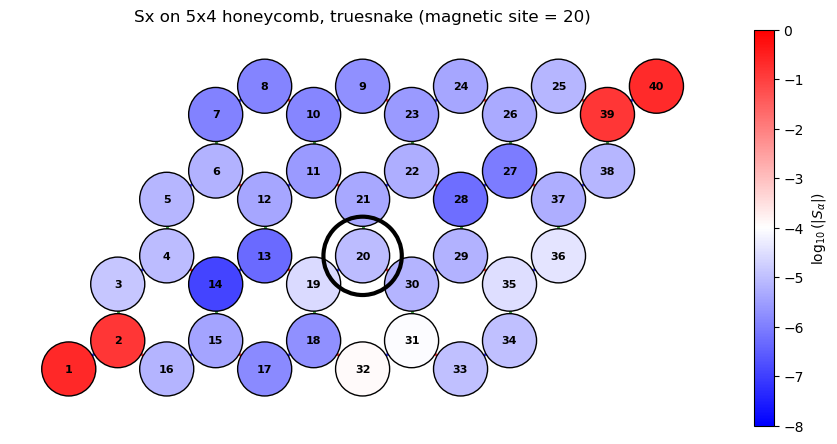

In [5]:
plot_current_lattice(
    plot_type="truesnake",
    log_abs=True,
    vmin=-8,
    vmax=0,
)

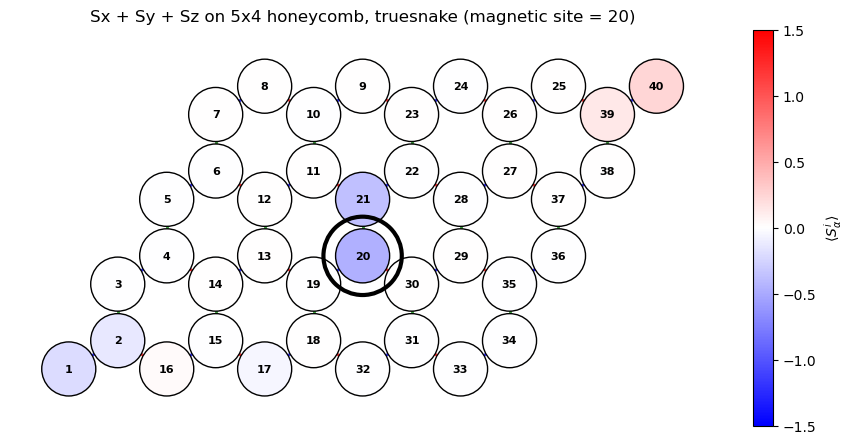

In [6]:
plot_current_spin_sum(plot_type="truesnake")  # snake_rows data is not available in results/

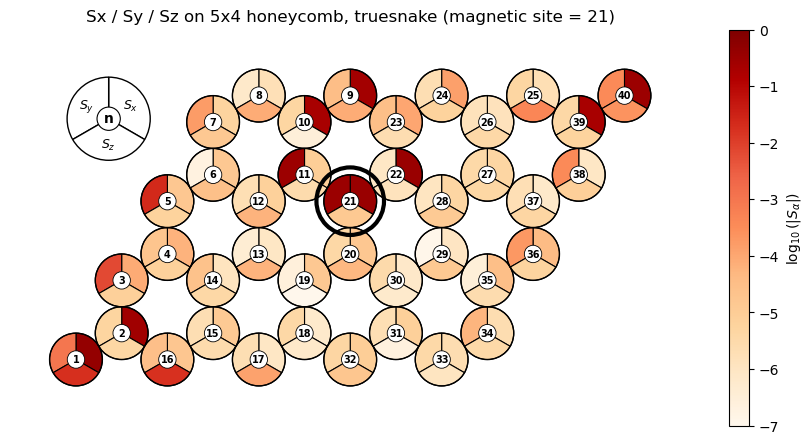

In [43]:
tab20 = plt.get_cmap("Paired")
colors8 = tab20(np.arange(0, 8))#[::-1]
cmap8 = ListedColormap(colors8)

plot_current_all_spin_components(
    plot_type="truesnake",
    radius_scale=0.5,
    log_abs=True,
    vmin=-7.0,
    vmax=0.0,
    eps=1e-12,
    cmap="OrRd",
)

Reading from:
results/truesnake/5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=1.0/Savrg_theta=1.5707963267948966_phi=0.7853981633974483_20/dmrg_log.dat


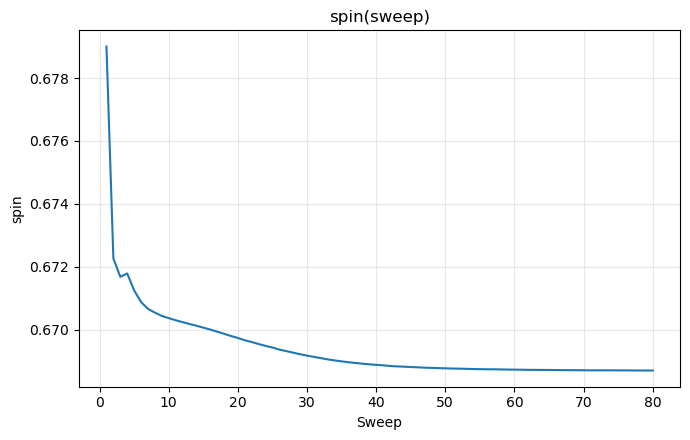

,sweep,energy,spin,maxdim,dmrg_maxerr
0,1,-7.299819,0.679004,50,1.171495e-04
1,2,-7.364979,0.672264,100,4.165898e-05
2,3,-7.393258,0.671680,150,5.405902e-05
3,4,-7.421976,0.671787,200,4.968913e-05
4,5,-7.437172,0.671252,300,1.195030e-05
...,...,...,...,...,...
75,76,-7.447764,0.668705,1317,8.201960e-08
76,77,-7.447754,0.668703,1342,5.292177e-08
77,78,-7.447762,0.668702,1325,3.409923e-08
78,79,-7.447753,0.668701,1304,1.283360e-07


In [47]:
#["energy", "spin", "maxdim", "dmrg_maxerr"]
plot_dmrg_quantity(
    plot_quantity="spin",
    plot_type="truesnake",
    angles="all",
    marker=None,
    mg_site_val=20,
)

In [ ]:
plot_current_all_spin_correlations(ref_site=13, vmin=-7, vmax=0, log_abs=True, 
                                   radius_scale=0.5, cmap="OrRd")

In [45]:
line_sites, pairs, corr_values = plot_current_line_pair_spin_correlations(
    ref_site=20,
    direction="horizontal",
    plot_type="truesnake",
    log_y=True,
)

FileNotFoundError: Nie znaleziono pliku:
results\truesnake\5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=1.0\Savrg_theta=1.5707963267948966_phi=0.7853981633974483_21\Sx_corr.dat

Site'y na wybranej linii:
[5, 6, 12, 11, 21, 22, 28, 27, 37, 38]


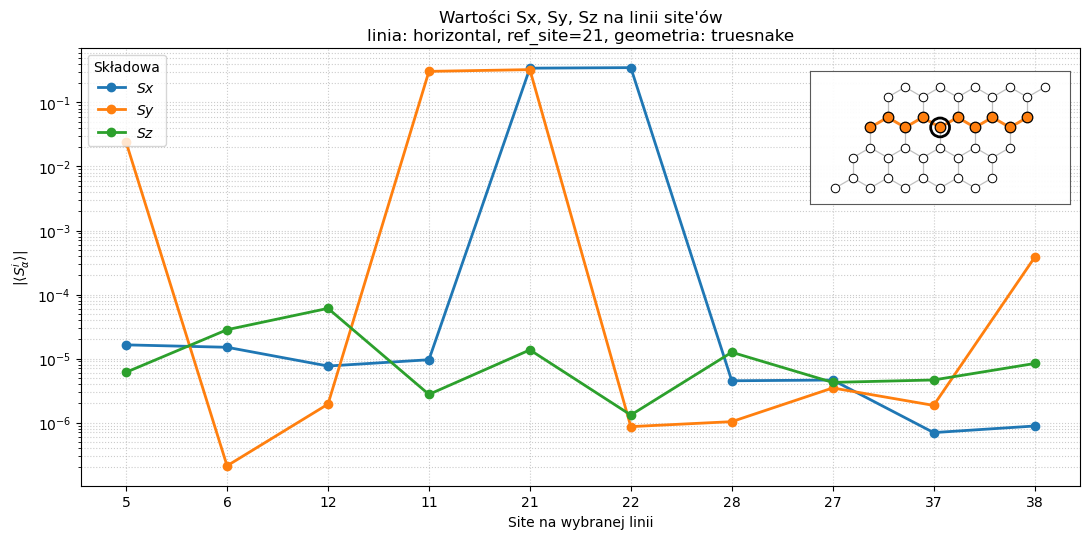

In [44]:
line_sites, spin_values = plot_current_line_spin_values(
    ref_site=21,
    direction="horizontal", #horizontal, vertical_xz, vertical_yz
    plot_type="truesnake",
    log_y=True,
)